<link rel="stylesheet" type="text/css" href="./css/styles.css" style="display: none;">
<script>
   document.addEventListener("DOMContentLoaded", function() {
       var links = document.querySelectorAll('link[href="./css/styles.css"]');
       links.forEach(function(l) { l.parentNode.style.display = 'none'; });
   });
</script>

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

## Analisi prezzi e mix produttivo in Europa

L’aumento dei prezzi dell’energia in Europa rende importante capire il legame tra produzione, mix energetico e prezzi. <br>
L’interesse nasce dalla volontà di comprendere il costo reale dell’energia.

Le domande a cui si cercherà di dare una risposta sono:
 - *Q1:* **Che relazione esiste tra energia pulita e prezzo dell'elettricità?**
 - *Q2*: **Il nucleare è associato a una minore variabilità del prezzo dell’elettricità?**
 - *Q3*: **Che relazione esiste tra energia fossile e prezzo dell’elettricità?**
 - *Q4*: **Quanto influenzano le importazioni sul prezzo dell’elettrici?**
 - *Q5*: **Quali caratteristiche strutturali del mix energetico presentano i paesi con i prezzi più elevati dell’elettricità?**

# Dataset utilizzati
I dati utilizzati provengono da Ember e sono i seguenti:

1. *Yearly Electricity Data* <br>
    Fonte: **Ember – Global Electricity Data** (https://ember-energy.org/data/yearly-electricity-data/) <br>
    Creato da: *[Nicolas Fulghum](https://ember-energy.org/people/nicolas-fulghum/)* <br>
    Dati disponibili: *dal 2000 al 2024* <br>
    Contiene informazioni annuali sulla produzione, capacità, import/export, domanda ed emissioni di energia elettrica per oltre 200 paesi e territori.

3. *European Wholesale Electricity Prices – Monthly* <br>
    Fonte: **Ember – European Wholesale Electricity Price Data** (https://ember-energy.org/data/european-wholesale-electricity-price-data/) <br>
    Creato da: *[Leonard Heberer](https://ember-energy.org/people/leo-heberer/)* <br>
    Dati disponibili: *dal 2015 al 2025* <br>
    Contiene i prezzi mensili all’ingrosso dell’elettricità in Europa (€/MWh), aggregati per paese. <br>

<i>La mancanza di dati sui costi energetici globali ha limitato l'analisi ai <b>soli paesi europei.</b></i>

## Dati utilizzati nell'analisi
I dataset contengono i seguenti dati (**verde** = dati usati nell'analisi):

**1. Yearly Electricity Data**
- <span style="color: green; font-weight: bold">Generazione elettrica (TWh)</span>, per tipo di carburante e aggregati
- <span style="color: green; font-weight: bold">Importazioni (TWh)</span>
- <span style="color: green; font-weight: bold">Domanda elettrica (TWh)</span>
- Capacità generativa (GW), per tipo di carburante
- Emissioni elettriche (Mt CO2e), calcolate dai fattori IPCC

<img src="../images/fuel_types_mapping.png" width="900">

**2. European Wholesale Electricity Prices – Monthly**
- <span style="color: green; font-weight: bold">Prezzo all'ingrosso (EUR/MWhe)</span>

# Analisi — Premessa
L'analisi si svolge in un contesto di forte stress di mercato, i meccanismi di formazione del prezzo potrebbero emergere con maggiore chiarezza rispetto a periodi di stabilità.

Come punto di riferimento è stato preso l'anno 2022:
- **Crisi del gas e prezzi record** [(invasione russa, prezzo europeo fino +300 €/MWh)](https://www.consilium.europa.eu/it/infographics/a-market-mechanism-to-limit-excessive-gas-price-spikes/)
- **Siccità storica** [(mancanza precipitazioni a livello europeo, calo produzione idroelettrica del 21%)](https://www.energiaitalia.news/news/idroelettrico/idroelettrico-produzione-crollata-del-35-nel-2022-il-dato-peggiore-degli-ultimi-10-anni/16632/)
- **Indisponibilità del nucleare** [(manutenzione centrali Francesi, calo produzione da nucleare del 16,7%)](https://www.fondazionesvilupposostenibile.org/calata-nel-2022-la-produzione-nucleare-nella-ue-167/#:~:text=ENERGIA%20E%20CLIMA-,Calata%20nel%202022%20la%20produzione%20nucleare%20nella%20Ue%2C%20%2D16%2C,%2C7%25%20rispetto%20al%202021.)
- **Stress climatico** [(ondate di calore, domanda europea fino +15%)](https://www.i-com.it/2025/07/18/ondate-calore-stress-elettrico-rete/)

## Q1: Energia pulita vs prezzo dell’elettricità
Obiettivo: capire se, a parità di anno, i paesi con maggiore quota di energia pulita hanno prezzi medi dell’elettricità più alti.

L’energia pulita ha criticità rispetto alle fonti fossili, soprattutto **la programmaticità della produzione**, influenzata da fattori ambientali.

Si ipotizza quindi che i paesi più green possano avere **prezzi dell’elettricità leggermente maggiori**.

### Quota energia pulita vs Prezzo elettricità

In [2]:
with open('../data/pickles/dataframe_q1.pickle', 'rb') as handle:
    year, df_y = list(pickle.load(handle).items())[0]

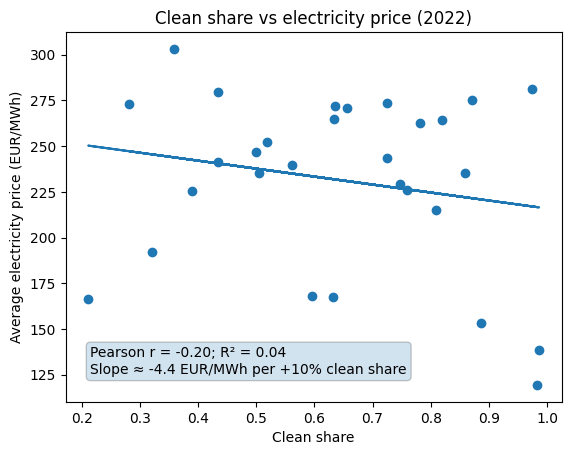

In [3]:
x = df_y["clean_share"]
y = df_y["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)
corr = df_y["clean_share"].corr(df_y["AvgPrice_EUR_MWh"])

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + q)
plt.xlabel("Clean share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Clean share vs electricity price ({year})")

plt.annotate(
    f"Pearson r = {corr:.2f}; R² = {corr**2:.2f}\n"
    f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% clean share",
    xy=(0.05, 0.15),
    xycoords="axes fraction",
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.show()

Un'alta quota di energia pulita è associata ad un lieve abbassamento dei prezzi, anche se la relazione è debolemnte negativa (r=-0.20). <br>
Per questo motivo l'analisi viene scomposta in energia rinnovabile e nucleare

### Quota energia rinnovabile vs Prezzo elettricità

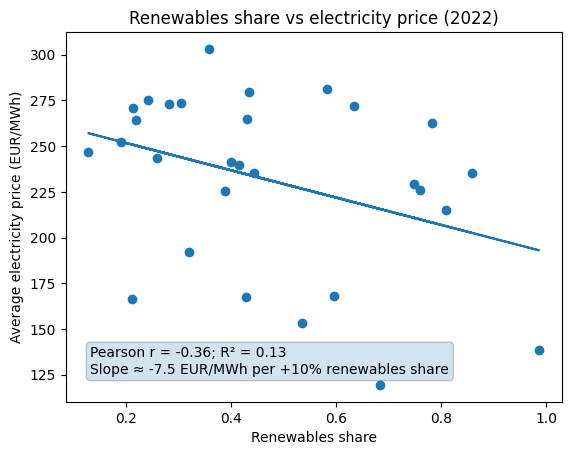

In [4]:
x = df_y["renewables_share"]
y = df_y["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)
corr = df_y["renewables_share"].corr(df_y["AvgPrice_EUR_MWh"])

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + q)
plt.xlabel("Renewables share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Renewables share vs electricity price ({year})")

plt.annotate(
    f"Pearson r = {corr:.2f}; R² = {corr**2:.2f}\n"
    f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% renewables share",
    xy=(0.05, 0.15),
    xycoords="axes fraction",
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.show()

Un'alta quota di rinnovabili è associata ad una moderata riduzione dei prezzi: la relazione è moderatamente negativa (r= -0.36).

### Quota energia nucleare vs Prezzo elettricità

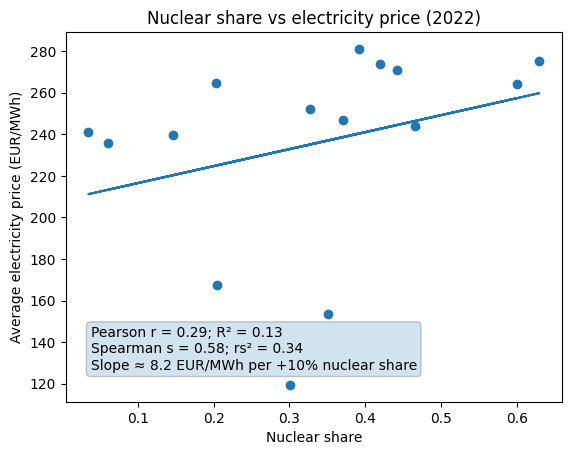

In [5]:
with_nuclear = df_y[df_y["Has_Nuclear"]]

x = with_nuclear["nuclear_share"]
y = with_nuclear["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)
corr_p = with_nuclear["nuclear_share"].corr(with_nuclear["AvgPrice_EUR_MWh"])
corr_s = with_nuclear["nuclear_share"].corr(with_nuclear["AvgPrice_EUR_MWh"], method="spearman")

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + q)
plt.xlabel("Nuclear share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Nuclear share vs electricity price ({year})")

plt.annotate(
    f"Pearson r = {corr_p:.2f}; R² = {corr**2:.2f}\nSpearman s = {corr_s:.2f}; rs² = {corr_s**2:.2f}\n"
    f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% nuclear share",
    xy=(0.05, 0.205),
    xycoords="axes fraction",
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.show()

Un'alta quota di energia prodotta dal nucleare è associata ad un moderato innalzamento dei prezzi: la relazione è debolmente positiva per Pearson (r = 0.29), ma è moderatamente positiva per Spearman (s = 0.58)

## Limite dell'analisi
Lo share di una fonte sul totale della produzione nazionale non garantisce che tale fonte determini il prezzo dell’elettricità. <br>
La variabilità dei prezzi possono essere influenzati ma molteplici fattori, variabilità elevata

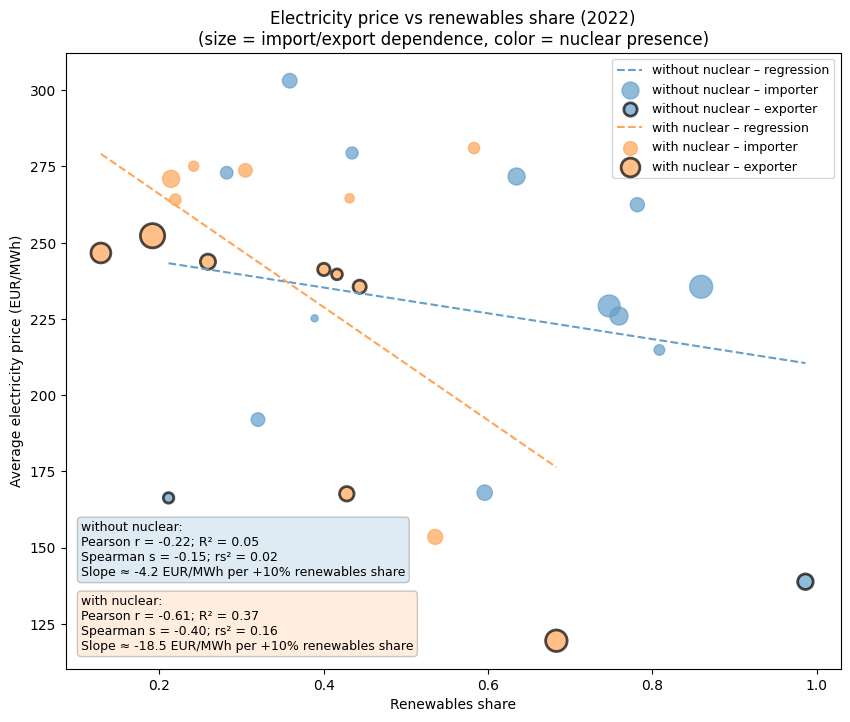

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

for i, (label, g) in enumerate(df_y.groupby("Has_Nuclear")):
    label_str = "with nuclear" if label else "without nuclear"
    color = "#ffa556" if label else "#629fca"

    # regressione
    x = g["renewables_share"]
    y = g["AvgPrice_EUR_MWh"]
    
    m, q = np.polyfit(x, y, 1)

    regression_x = [min(x), max(x)]
    regression_y = [m*_x + q for _x in regression_x]
    
    ax.plot(
        regression_x,
        regression_y,
        color=color,
        linestyle="--",
        linewidth=1.5,
        label=f"{label_str} – regression",
    )

    # scatter punti
    imp = g[g["is_importer"]]
    ax.scatter(
        imp["renewables_share"],
        imp["AvgPrice_EUR_MWh"],
        s=300 * np.sqrt(imp["import_share"]),
        alpha=0.7,
        color=color,
        label=f"{label_str} – importer",
    )

    exp = g[~g["is_importer"]]
    ax.scatter(
        exp["renewables_share"],
        exp["AvgPrice_EUR_MWh"],
        s= 800 * exp["import_share"] + 50,
        alpha=0.7,
        edgecolors="black",
        linewidth=2,
        facecolors=color,
        label=f"{label_str} – exporter",
    )

    corr_p = g["renewables_share"].corr(g["AvgPrice_EUR_MWh"])
    corr_s = g["renewables_share"].corr(g["AvgPrice_EUR_MWh"], method="spearman")

    ax.annotate(
        f"{label_str}:\n"
        f"Pearson r = {corr_p:.2f}; R² = {corr_p**2:.2f}\nSpearman s = {corr_s:.2f}; rs² = {corr_s**2:.2f}\n"
        f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% renewables share",
        xy=(0.02, 0.24 - i*0.12), 
        xycoords="axes fraction",
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", alpha=0.2, facecolor=color)
    )

ax.set_xlabel("Renewables share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title(
    f"Electricity price vs renewables share ({year})\n"
    "(size = import/export dependence, color = nuclear presence)"
)

ax.legend(fontsize=9)
plt.show()

Il grafico mostra che:
- una quota elevata di energia rinnovabile non implica necessariamente prezzi medi dell’elettricità più bassi. <br>
- le nazioni che principalmente importano corrente hanno tendenzialmene prezzi più alti.<br>
- il nucleare sembra implichi una variabilità di prezzo minore.<br>

### Q2: Il nucleare è associato a una minore variabilità del prezzo dell’elettricità?
L’obiettivo è valutare se la presenza del nucleare sia associata a una minore variabilità o a una diversa dispersione dei prezzi.

In [7]:
with open('../data/pickles/dataframe_q2.pickle', 'rb') as handle:
    year, df_y = list(pickle.load(handle).items())[0]

In [8]:
with_nuclear = df_y[df_y["Has_Nuclear"]]
without_nuclear = df_y[~df_y["Has_Nuclear"]]

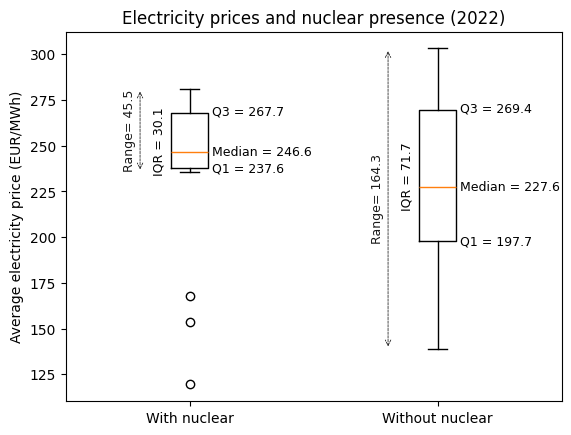

In [9]:
plt.figure()

data = [
    with_nuclear["AvgPrice_EUR_MWh"],
    without_nuclear["AvgPrice_EUR_MWh"]
]

labels = ["With nuclear", "Without nuclear"]

bp = plt.boxplot(data, tick_labels=labels)

plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Electricity prices and nuclear presence ({year})")

# --- Calcolo statistiche ---
def box_stats(series):
    q1 = series.quantile(0.25)
    med = series.median()
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    whisker_low = series[series >= q1 - 1.5*iqr].min()
    whisker_high = series[series <= q3 + 1.5*iqr].max()
    return q1, med, q3, iqr, whisker_low, whisker_high


# Calcolo quantili
stats = [
    box_stats(d)
    for d in data
]

# Annotazioni
for i, (q1, med, q3, iqr, whisker_low, whisker_high) in enumerate(stats, start=1):

    plt.text(i + 0.09, q1, f"Q1 = {q1:.1f}", va="center", fontsize=9)
    plt.text(i + 0.09, med, f"Median = {med:.1f}", va="center", fontsize=9)
    plt.text(i + 0.09, q3 + 1, f"Q3 = {q3:.1f}", va="center", fontsize=9)
    plt.text(i - 0.15, q1 + iqr/2, f"IQR = {iqr:.1f}", ha="left", va="center", fontsize=9, rotation =90)

    plt.annotate(
        '', 
        xy=(i - 0.2, whisker_high),      # punta
        xytext=(i - 0.2, whisker_low),                       # origine
        arrowprops=dict(arrowstyle='<->', linestyle = "--", color='black', lw=0.5)
    )

    plt.text(
        i - 0.27,
        (whisker_high + whisker_low)/2,
        f"Range= {whisker_high-whisker_low:.1f}",
        ha="left",
        va="center",
        fontsize=9,
        rotation=90,
        alpha=0.9
    )

plt.show()

Nei paesi con nucleare i prezzi risultano concentrati in un intervallo più ristretto, suggerisce un effetto di stabilizzazione.

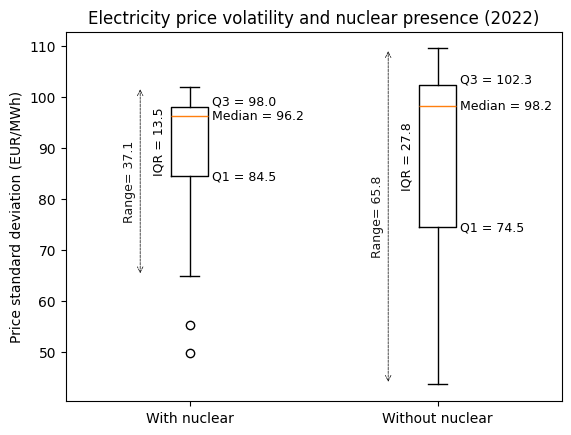

In [10]:
plt.figure()

data = [
    with_nuclear["StdPrice_EUR_MWh"],
    without_nuclear["StdPrice_EUR_MWh"]
]

labels = ["With nuclear", "Without nuclear"]

plt.boxplot(data, tick_labels=labels)

plt.ylabel("Price standard deviation (EUR/MWh)")
plt.title(f"Electricity price volatility and nuclear presence ({year})")


# --- Calcolo statistiche ---
def box_stats(series):
    q1 = series.quantile(0.25)
    med = series.median()
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    whisker_low = series[series >= q1 - 1.5*iqr].min()
    whisker_high = series[series <= q3 + 1.5*iqr].max()
    return q1, med, q3, iqr, whisker_low, whisker_high


# Calcolo quantili
stats = [
    box_stats(d)
    for d in data
]

# Annotazioni
for i, (q1, med, q3, iqr, whisker_low, whisker_high) in enumerate(stats, start=1):

    plt.text(i + 0.09, q1, f"Q1 = {q1:.1f}", va="center", fontsize=9)
    plt.text(i + 0.09, med, f"Median = {med:.1f}", va="center", fontsize=9)
    plt.text(i + 0.09, q3 + 1, f"Q3 = {q3:.1f}", va="center", fontsize=9)
    plt.text(i - 0.15, q1 + iqr/2, f"IQR = {iqr:.1f}", ha="left", va="center", fontsize=9, rotation =90)

    plt.annotate(
        '', 
        xy=(i - 0.2, whisker_high),      # punta
        xytext=(i - 0.2, whisker_low),                       # origine
        arrowprops=dict(arrowstyle='<->', linestyle = "--", color='black', lw=0.5)
    )

    plt.text(
        i - 0.27,
        (whisker_high + whisker_low)/2,
        f"Range= {whisker_high-whisker_low:.1f}",
        ha="left",
        va="center",
        fontsize=9,
        rotation=90,
        alpha=0.9
    )

plt.show()


La volatilità dei prezzi nelle nazioni con nucleare è moderatamente inferiore rispetto a quella delle nazioni senza nucleare, suggerendo una prevedibilità maggiore.

### Q3: Energia fossile e prezzo dell’elettricità
L’obiettivo è verificare se, a parità di anno, una maggiore quota di produzione da fonti fossili sia associata a prezzi medi dell’elettricità più bassi.

In [11]:
with open('../data/pickles/dataframe_q3.pickle', 'rb') as handle:
    year, df_y = list(pickle.load(handle).items())[0]

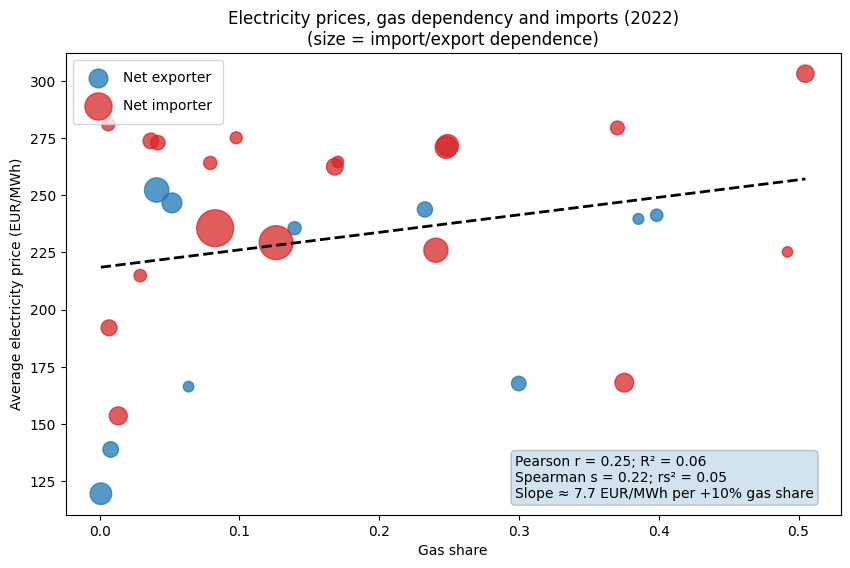

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {True: "#d62728", False: "#1f77b4"}
labels = {True: "Net importer", False: "Net exporter"}

for is_imp, g in df_y.groupby("is_importer"):
    ax.scatter(
        g["gas_share"],
        g["AvgPrice_EUR_MWh"],
        s= 800 * g["import_share"] + 50,
        alpha=0.75,
        color=colors[is_imp],
        label=labels[is_imp],
    )

x = df_y["gas_share"]
y = df_y["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)

regression_x = [min(x), max(x)]
regression_y = [m*_x + q for _x in regression_x]

ax.plot(regression_x, regression_y, color="black", linestyle="--", linewidth=2)

corr_p = df_y["gas_share"].corr(df_y["AvgPrice_EUR_MWh"])
corr_s = df_y["gas_share"].corr(df_y["AvgPrice_EUR_MWh"], method="spearman")

plt.annotate(
    f"Pearson r = {corr_p:.2f}; R² = {corr_p**2:.2f}\nSpearman s = {corr_s:.2f}; rs² = {corr_s**2:.2f}\n"
    f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% gas share",
    xy=(0.58, 0.13),
    xycoords="axes fraction",
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

ax.set_xlabel("Gas share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title(
    "Electricity prices, gas dependency and imports (2022)\n"
    "(size = import/export dependence)"
)

ax.legend(borderpad=0.8, labelspacing=1)
plt.show()

Un'alta quota di dipendenza dal gas è associata ad un lieve aumento dei prezzi, ma la dispersione è alta (r ≈ 0.25, R² ≈ 0.06). <br>
La distinzione tra net importer e net exporter suggerisce comportamenti diversi, ma non sufficienti a spiegare il prezzo.

Nel grafico successivo verrà aggiunta ulteriore struttura: 
- evidenziamo la presenza del carbone;
- distinguiamo esportatori e importatori;
- introduciamo l’intensità della dipendenza dagli scambi;
  
L’obiettivo è capire se questa relazione debole nasconde dinamiche diverse tra gruppi di paesi.

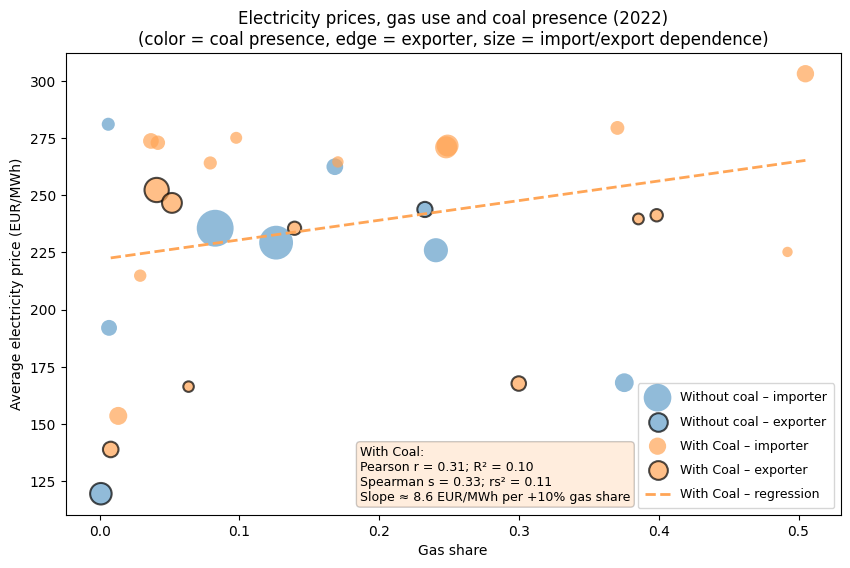

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {True: "#ffa556", False: "#629fca"}
labels = {True: "With Coal", False: "Without coal"}

handles = []  # per la legenda
legend_labels = []

for i, (label, g) in enumerate(df_y.groupby("Has_coal")):
    color = colors[label]
    group_name = labels[label]

    # scatter punti
    imp = g[g["is_importer"]]
    exp = g[~g["is_importer"]]

    sc_imp = ax.scatter(
        imp["gas_share"],
        imp["AvgPrice_EUR_MWh"],
        s=800 * imp["import_share"] + 50,
        alpha=0.7,
        color=color,
        edgecolors="none"
    )
    sc_exp = ax.scatter(
        exp["gas_share"],
        exp["AvgPrice_EUR_MWh"],
        s=800 * exp["import_share"] + 50,
        alpha=0.7,
        edgecolors="black",
        linewidth=1.5,
        facecolors=color
    )

    handles.extend([sc_imp, sc_exp])
    legend_labels.extend([f"{group_name} – importer", f"{group_name} – exporter"])

    # regressione
    x = g["gas_share"]
    y = g["AvgPrice_EUR_MWh"]
    
    corr_p = g["gas_share"].corr(g["AvgPrice_EUR_MWh"])
    corr_s = g["gas_share"].corr(g["AvgPrice_EUR_MWh"], method="spearman")

    if abs(corr_p) >= 0.05:
        m, q = np.polyfit(x, y, 1)
        
        regression_x = [min(x), max(x)]
        regression_y = [m*_x + q for _x in regression_x]
        reg_line, = ax.plot(
            regression_x,
            regression_y,
            linestyle="--",
            linewidth=2,
            color=color
        )
        handles.append(reg_line)
        legend_labels.append(f"{group_name} – regression")

        # annotazioni
        ax.annotate(
            f"{group_name}:\n"
            f"Pearson r = {corr_p:.2f}; R² = {corr_p**2:.2f}\nSpearman s = {corr_s:.2f}; rs² = {corr_s**2:.2f}\n"
            f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% gas share",
            xy=(0.38, 0.28 - i*0.13),
            xycoords="axes fraction",
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", alpha=0.2, facecolor=color)
        )

ax.set_xlabel("Gas share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title(
    "Electricity prices, gas use and coal presence (2022)\n"
    "(color = coal presence, edge = exporter, size = import/export dependence)"
)

ax.legend(handles=handles, labels=legend_labels, fontsize=9, borderpad=0.6, labelspacing=0.9)
plt.show()

I paesi con carbone mostrano una correlazione più accentuata tra uso del gas e prezzo dell’elettricità. <br>
Casi con prezzi più elevati tendono a combinare gas, carbone e dipendenza dalle importazioni.

Introducendo la presenza del carbone, la relazione tra gas share e prezzo diventa più leggibile. <br>
I paesi con carbone nel mix mostrano una correlazione più chiara tra uso del gas e prezzo dell’elettricità (r ≈ 0.31, R² ≈ 0.10), con una pendenza più ripida rispetto al caso aggregato. <br>
Questo suggerisce che il gas incide di più sui prezzi quando convive con fonti fossili rigide come il carbone, probabilmente perché il mix è meno flessibile e più esposto ai costi marginali del gas.

### Q4: Quanto influenzano le importazioni sul prezzo dell’elettricità?
Un’elevata produzione nazionale da fonti pulite o fossili non garantisce prezzi bassi se il fabbisogno interno supera la produzione e il paese dipende dalle importazioni.

In [14]:
with open('../data/pickles/dataframe_q4.pickle', 'rb') as handle:
    year, df_y = list(pickle.load(handle).items())[0]

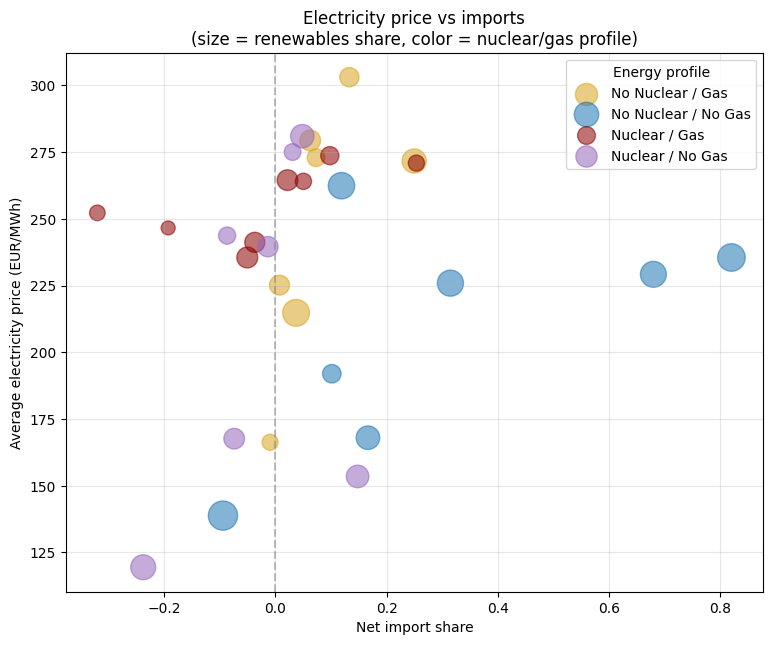

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))

color_map = {
"No Nuclear / No Gas": "tab:blue",
"No Nuclear / Gas": "goldenrod",
"Nuclear / No Gas": "tab:purple",
"Nuclear / Gas": "darkred"
}

for label, g in df_y.groupby("Energy_Category"):
    ax.scatter(
        g["import_share"],
        g["AvgPrice_EUR_MWh"],
        color=color_map[label],
        s=400 * g["renewables_share"] + 50,
        alpha=0.55,
        label=label
    )

ax.axvline(0, linestyle="--", color="gray", alpha=0.5)
ax.set_xlabel("Net import share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title(
    "Electricity price vs imports\n"
    "(size = renewables share, color = nuclear/gas profile)"
)
ax.legend(title="Energy profile")
plt.grid(alpha=0.3)
plt.show()

I paesi dotati di produzione di corrente elettrica costante tendono ad avere una minore dipendenza dalle importazioni.


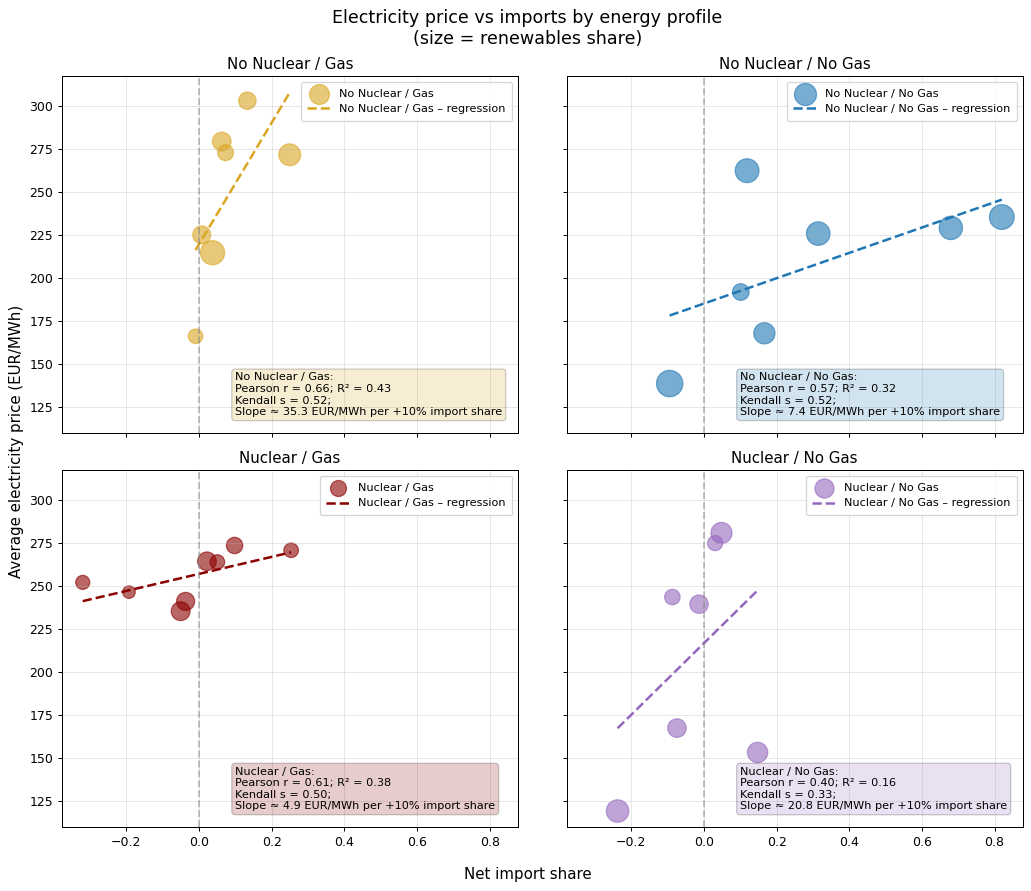

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True, dpi=90)
axes = axes.flatten()

color_map = {
    "No Nuclear / No Gas": "tab:blue",
    "No Nuclear / Gas": "goldenrod",
    "Nuclear / No Gas": "tab:purple",
    "Nuclear / Gas": "darkred"
}

for ax, (label, g) in zip(axes, df_y.groupby("Energy_Category")):
    handles = []
    legend_labels = []
    group_name = label
    x = g["import_share"]
    y = g["AvgPrice_EUR_MWh"]
    sc = ax.scatter(
        x,
        y,
        color=color_map[group_name],
        s=400 * g["renewables_share"] + 50,
        alpha=0.6
    )

    handles.append(sc)
    legend_labels.append(f"{group_name}")


    corr_p = g["import_share"].corr(g["AvgPrice_EUR_MWh"])
    corr_t = g["import_share"].corr(g["AvgPrice_EUR_MWh"], method="kendall")

    if abs(corr_p) >= 0.05:
        m, q = np.polyfit(x, y, 1)
        
        regression_x = [min(x), max(x)]
        regression_y = [m*_x + q for _x in regression_x]
        reg_line, = ax.plot(
            regression_x,
            regression_y,
            linestyle="--",
            linewidth=2,
            color=color_map[group_name]
        )
        handles.append(reg_line)
        legend_labels.append(f"{group_name} – regression")

        # annotazioni
        ax.annotate(
            f"{group_name}:\n"
            f"Pearson r = {corr_p:.2f}; R² = {corr_p**2:.2f}\nKendall s = {corr_t:.2f};\n"
            f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% import share",
            xy=(0.38, 0.17),
            xycoords="axes fraction",
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", alpha=0.2, facecolor=color_map[group_name])
        )

    ax.legend(handles=handles, labels=legend_labels, fontsize=9, borderpad=0.6, labelspacing=0.5)
    
    ax.axvline(0, linestyle="--", color="gray", alpha=0.5)
    ax.set_title(label)
    ax.grid(alpha=0.3)

# etichette comuni
fig.supxlabel("Net import share")
fig.supylabel("Average electricity price (EUR/MWh)")

fig.suptitle(
    "Electricity price vs imports by energy profile\n"
    "(size = renewables share)",
    fontsize=14
)

plt.tight_layout()
plt.show()

Suddividendo i vari paesi in base al profilo energetico emerge che i vari prezzi energetici sono fortemente influenzati dalle quote di importazione in funzione alle fonti utilizzate.

Segmentando i paesi in base alla presenza di nucleare e gas emerge che i paesi dotati di produzione di corrente elettrica costante (nucleare e/o carbone) tendono ad avere una minore dipendenza dalle importazioni. Al contrario, i paesi con un’elevata quota di rinnovabili e assenza di fonti programmate mostrano una maggiore dipendenza al mercato estero, con effetti rilevanti sul prezzo finale dell’elettricità.

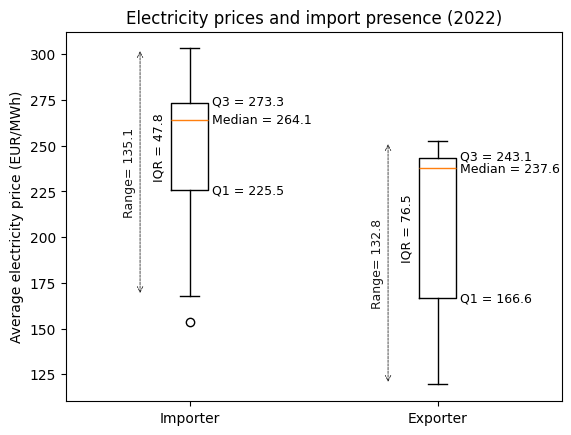

In [17]:
plt.figure()

data = [
    df_y[df_y["Is_Importer"]]["AvgPrice_EUR_MWh"],
    df_y[~df_y["Is_Importer"]]["AvgPrice_EUR_MWh"]
]

labels = ["Importer", "Exporter"]

plt.boxplot(data, tick_labels=labels)

plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Electricity prices and import presence ({year})")


# --- Calcolo statistiche ---
def box_stats(series):
    q1 = series.quantile(0.25)
    med = series.median()
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    whisker_low = series[series >= q1 - 1.5*iqr].min()
    whisker_high = series[series <= q3 + 1.5*iqr].max()
    return q1, med, q3, iqr, whisker_low, whisker_high


# Calcolo quantili
stats = [
    box_stats(d)
    for d in data
]

# Annotazioni
for i, (q1, med, q3, iqr, whisker_low, whisker_high) in enumerate(stats, start=1):

    plt.text(i + 0.09, q1, f"Q1 = {q1:.1f}", va="center", fontsize=9)
    plt.text(i + 0.09, med, f"Median = {med:.1f}", va="center", fontsize=9)
    plt.text(i + 0.09, q3 + 1, f"Q3 = {q3:.1f}", va="center", fontsize=9)
    plt.text(i - 0.15, q1 + iqr/2, f"IQR = {iqr:.1f}", ha="left", va="center", fontsize=9, rotation =90)

    plt.annotate(
        '', 
        xy=(i - 0.2, whisker_high),      # punta
        xytext=(i - 0.2, whisker_low),                       # origine
        arrowprops=dict(arrowstyle='<->', linestyle = "--", color='black', lw=0.5)
    )

    plt.text(
        i - 0.27,
        (whisker_high + whisker_low)/2,
        f"Range= {whisker_high-whisker_low:.1f}",
        ha="left",
        va="center",
        fontsize=9,
        rotation=90,
        alpha=0.9
    )

plt.show()

I paesi importatori presentano prezzi medi dell’elettricità più elevati ma con una dispersione inferiore.
I paesi esportatori mostrano una maggiore variabilità dei prezzi.

Il boxplot evidenzia che i paesi importatori presentano prezzi medi dell’elettricità più elevati ma con una dispersione inferiore rispetto agli esportatori. Al contrario, i paesi esportatori mostrano una maggiore variabilità dei prezzi, suggerendo modelli energetici più eterogenei e una minore dipendenza da un prezzo comune.

### Q5: Quali caratteristiche strutturali del mix energetico presentano i paesi con i prezzi più elevati dell’elettricità?
L'obiettivo è capire se esistono dei tratti comuni tra i principali paesi che possiedono prezzi energetici più elevati

In [18]:
with open('../data/pickles/dataframe_q5.pickle', 'rb') as handle:
    year, df_y = list(pickle.load(handle).items())[0]

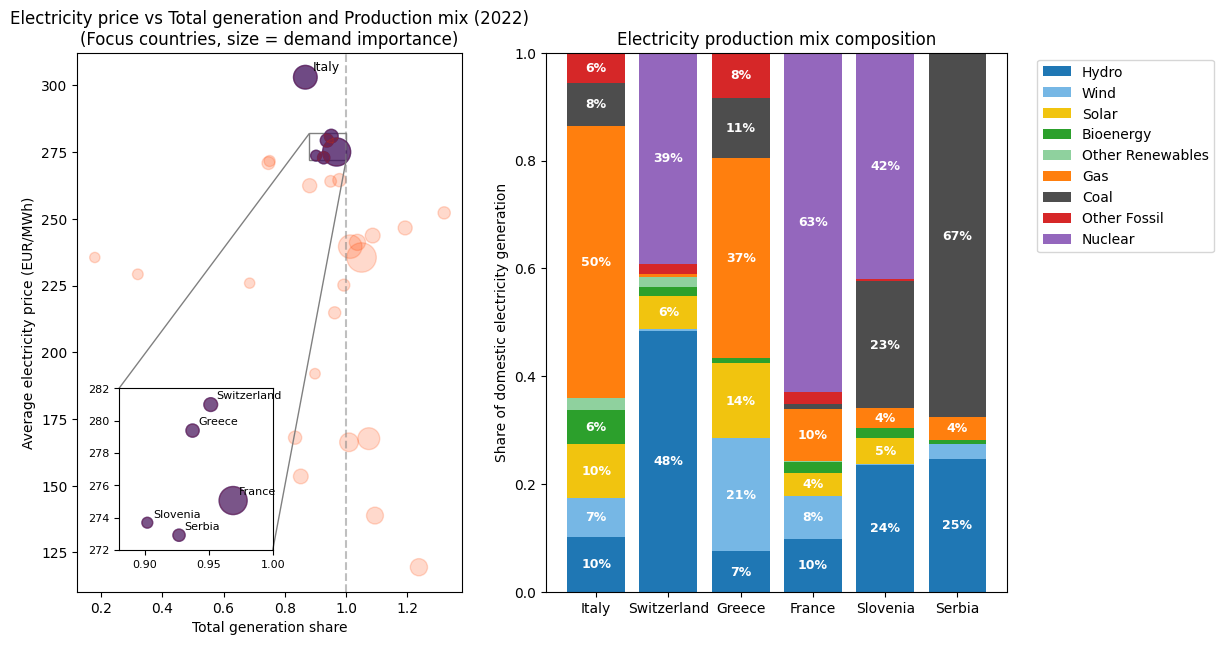

In [19]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

top_countries = (
    df_y
    .sort_values("AvgPrice_EUR_MWh", ascending=False)
    .head(6)["Area"]
)
top_countries

df_focus = df_y[df_y["Area"].isin(top_countries)].sort_values("AvgPrice_EUR_MWh", ascending=False).set_index("Area")


fig, axes = plt.subplots(1, 2, figsize=(12, 7), gridspec_kw={"width_ratios": [1, 1.2]})


# ======================
# PANNELLO 1 — SCATTER
# ======================
ax = axes[0]


# ---- INSET ZOOM ----

axins = inset_axes(
    ax,
    width="40%",
    height="30%",
    loc="lower left",
    borderpad=3
)

axins.scatter(
    df_focus["total_generation_share"],
    df_focus["AvgPrice_EUR_MWh"],
    color = "navy",
    s=400 * df_focus["demand_ratio"] + 50,
    alpha=0.65
)


axins.scatter(
    df_y["total_generation_share"],
    df_y["AvgPrice_EUR_MWh"],
    color = "orangered",
    s=400 * df_y["demand_ratio"] + 50,
    alpha=0.2
)

# limiti dello zoom per grafico inset
axins.set_xlim(0.88, 1.0)
axins.set_ylim(272, 282)

country_alreay_labels = []

for country, row in df_focus.iterrows():
    if 0.88 <= row["total_generation_share"] <= 1.0 and 272 <= row["AvgPrice_EUR_MWh"] <= 282:
        axins.annotate(
            country,
            (row["total_generation_share"], row["AvgPrice_EUR_MWh"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )
        country_alreay_labels.append(country)

axins.tick_params(labelsize=8)

# rettangolo + linee di collegamento
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="gray")

# ---- scatter points ---- #

ax.scatter(
    df_focus["total_generation_share"],
    df_focus["AvgPrice_EUR_MWh"],
    color = "navy",
    s= 400 * df_focus["demand_ratio"] + 50,
    alpha = 0.7
)

ax.scatter(
    df_y["total_generation_share"],
    df_y["AvgPrice_EUR_MWh"],
    color = "orangered",
    s= 400 * df_y["demand_ratio"] + 50,
    alpha = 0.2
)



for country, row in df_focus.iterrows():
    if country not in country_alreay_labels:
        ax.annotate(
            country,
            (row["total_generation_share"], row["AvgPrice_EUR_MWh"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )


ax.axvline(1, linestyle="--", color="gray", alpha=0.5)
ax.set_xlabel("Total generation share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title("Electricity price vs Total generation and Production mix (2022)\n"
            "(Focus countries, size = demand importance)")

# ============================
# PANNELLO 2 — STACKED BAR
# ============================
ax2 = axes[1]


energy_components = {
    "Hydro": df_focus["Hydro"],
    "Wind": df_focus["Wind"],
    "Solar": df_focus["Solar"],
    "Bioenergy": df_focus["Bioenergy"],
    "Other Renewables": df_focus["Other Renewables"],
    "Gas": df_focus["Gas"],
    "Coal": df_focus["Coal"],
    "Other Fossil": df_focus["Other Fossil"],
    "Nuclear": df_focus["Nuclear"],
}

energy_colors = {
    "Hydro": "#1f77b4",            # blu
    "Wind": "#76b7e5",             # azzurro
    "Solar": "#f1c40f",            # giallo
    "Bioenergy": "#2ca02c",        # verde
    "Other Renewables": "#8fd19e", # verde chiaro

    "Gas": "#ff7f0e",              # arancione
    "Coal": "#4d4d4d",             # quasi nero
    "Other Fossil": "#d62728",     # rosso scuro

    "Nuclear": "#9467bd",          # viola
}

bottom_energy_components = {}

bottom = np.zeros(len(df_focus))

for label, values in energy_components.items():
    share = (values / df_focus["Total Generation"]).to_numpy()

    bars = ax2.bar(
        df_focus.index,
        share,
        bottom=bottom,
        label=label,
        color=energy_colors[label]
    )

    for i, s in enumerate(share):
        if s > 0.03: 
            ax2.text(
                i, 
                bottom[i] + s / 2,
                f"{s*100:.0f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="white"
            )

    bottom += share
    

    

ax2.set_ylabel("Share of domestic electricity generation")
ax2.set_title("Electricity production mix composition")
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


#plt.tight_layout()
plt.show()

I paesi con i prezzi dell'elettricità più elevati, si distinguono per una maggiore dipendenza dal gas naturale, dal nucleare e dal carbone, oltre ad essere spesso importatori netti di energia.

## Analisi Dettagliata
Dall'analisi combinata del grafico e dei dati di mercato, emergono delle correlazioni significative tra la struttura del mix energetico e il costo medio dell'elettricità:
- **Dipendenza dai Combustibili Fossili (Gas)**: <br>
  I paesi con i prezzi più alti (Italia e Grecia) mostrano una quota significativa di produzione da gas. Il prezzo del gas naturale è stato storicamente volatile e spesso elevato sui mercati internazionali, influenzando direttamente il costo finale dell'elettricità, a causa dei meccanismi di formazione del prezzo all'ingrosso.
- **Quota di Nucleare e Idroelettrico**: <br>
  I paesi con prezzi mediamente più bassi (Francia e Svizzera) hanno una quota dominante di produzione da fonti stabili e a basso costo operativo come il nucleare (Francia) e l'idroelettrico (Svizzera). Queste fonti forniscono un carico di base (baseload) consistente e meno soggetto alle fluttuazioni dei prezzi del combustibile, contribuendo a calmierare il prezzo medio.
- **Importazioni Nette**: <br>
  L'Italia, in particolare, è un importatore netto di energia elettrica, anche dalla Francia. La dipendenza dalle importazioni espone il sistema energetico nazionale alle dinamiche dei prezzi e alla disponibilità dei paesi esportatori, contribuendo a costi più elevati.
- **Rinnovabili**:<br>
  Sebbene le energie rinnovabili stiano crescendo in tutti i paesi e contribuiscano a ridurre i prezzi quando disponibili, la loro intermittenza e la necessità di fonti di riserva flessibili (spesso a gas) significano che, nei mix dove le fossili sono ancora prevalenti, l'impatto sui prezzi medi elevati rimane.

## Struttura energetica e prezzo elettricità
Visione polare della composizione del mix produttivo energetico con prezzo e dipendenza estera codificate, rispettivamente, nel colore e nell'area dei punti

In [20]:
with open('../data/pickles/dataframe_sintesi.pickle', 'rb') as handle:
    year, df_y = list(pickle.load(handle).items())[0]

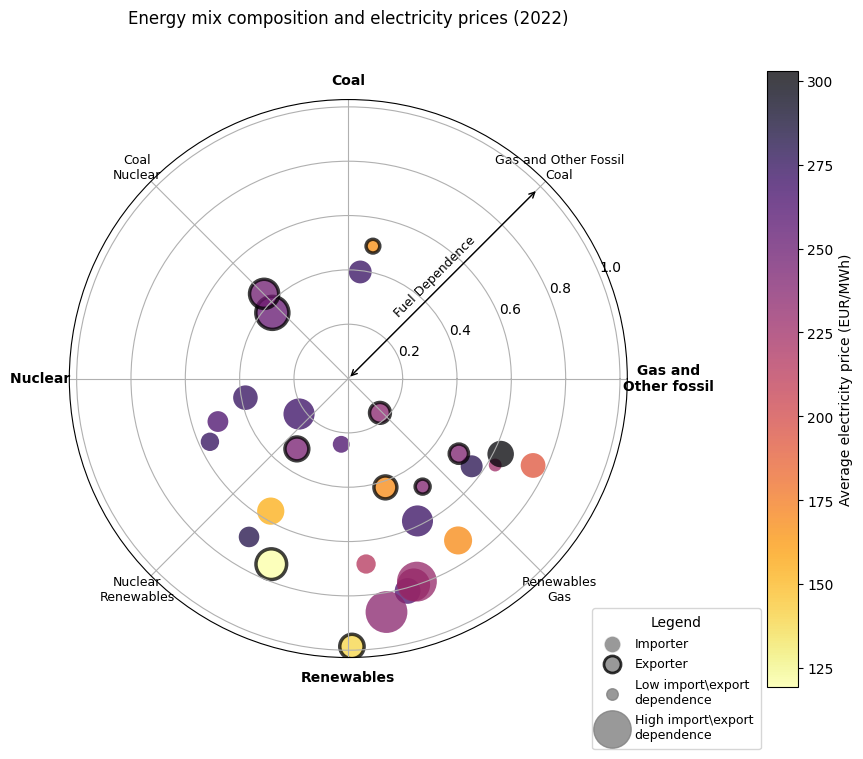

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches


label_angles = {
    "gas_and_other_fossil": 0,
    "coal": np.pi / 2,
    "nuclear": np.pi,
    "renewables": 3 * np.pi / 2
}

x = (
    df_y["gas_and_other_fossil_share"] * np.cos(label_angles["gas_and_other_fossil"]) +
    df_y["coal_share"] * np.cos(label_angles["coal"]) +
    df_y["nuclear_share"] * np.cos(label_angles["nuclear"]) +
    df_y["renewables_share"] * np.cos(label_angles["renewables"])
)

y = (
    df_y["gas_and_other_fossil_share"] * np.sin(label_angles["gas_and_other_fossil"]) +
    df_y["coal_share"] * np.sin(label_angles["coal"]) +
    df_y["nuclear_share"] * np.sin(label_angles["nuclear"]) +
    df_y["renewables_share"] * np.sin(label_angles["renewables"])
)

theta = np.arctan2(y, x)


# ---- labels grafico ---- #
labels = {
    "gas_and_other_fossil": "         Gas and\n         Other fossil",
    "coal": "Coal",
    "nuclear": "Nuclear    ",
    "renewables": "Renewables"
}

mid_labels_angles = {
    "Gas and Other Fossil\nCoal": (label_angles["gas_and_other_fossil"] + label_angles["coal"])/2,
    "Coal\nNuclear": (label_angles["coal"] + label_angles["nuclear"])/2,
    "Nuclear\nRenewables": (label_angles["nuclear"] + label_angles["renewables"])/2,
    "Renewables\nGas": (label_angles["renewables"] + 2 * np.pi)/2,
}

# ---- calcolo posizioni polari ---- #

x_total = np.zeros(len(df_y))
y_total = np.zeros(len(df_y))

for col, theta in label_angles.items():
    x_total += df_y[f"{col}_share"] * np.cos(theta)
    y_total += df_y[f"{col}_share"] * np.sin(theta)

theta_final = np.arctan2(y_total, x_total)
r_final = np.sqrt(x_total**2 + y_total**2)


fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection='polar')


# ---- posizionamento punti su grafico ---- #

sc = ax.scatter(
    theta_final,
    r_final,
    c=df_y["AvgPrice_EUR_MWh"],
    cmap="inferno_r", #'YlGnBu',
    s= 1000 * np.sqrt(df_y["import_share"]),
    edgecolors = np.where(df_y["is_importer"], "none", "black"),
    linewidth= np.where(df_y["is_importer"], 0, 2.5),
    alpha=0.75
)

# ---- posizionamento annotazioni ---- #

theta_arrow = np.pi/4
arrow_radius = 1 * r_final.max()


ax.annotate(
    '', 
    xy=(theta_arrow, arrow_radius),      # punta
    xytext=(0, 0),                       # origine
    arrowprops=dict(arrowstyle='<->', color='black', lw=1)
)

ax.text(
    theta_arrow + 0.08, 
    arrow_radius*0.5, 
    "Fuel Dependence", 
    rotation=45,
    ha='center', 
    va='center',                
    fontsize=9
)

# ---- legenda ---- #

# (import/export)
import_patch = plt.scatter([], [], marker='o', color='w', label='Importer', facecolor='gray', s=150, alpha=0.8)
export_patch = plt.scatter([], [], marker='o', color='black', label='Exporter', facecolor='gray', s=150, alpha=0.8, linewidth=2)


# (import share)
small = plt.scatter([], [], s=min(800 * np.sqrt(df_y["import_share"])), color='gray', alpha=0.8, label='Low import\\export\ndependence')
large = plt.scatter([], [], s=max(800 * np.sqrt(df_y["import_share"])), color='gray', alpha=0.8, label='High import\\export\ndependence')


# legend combinata
ax.legend(handles=[import_patch, export_patch, small, large],
loc='upper right', bbox_to_anchor=(1.25, 0.10), title='Legend', borderpad=0.6, labelspacing=0.6, fontsize=9)




plt.colorbar(sc, ax=ax, label="Average electricity price (EUR/MWh)", fraction=0.1, pad=0.18)
ax.set_title("Energy mix composition and electricity prices (2022)\n\n")

# set tick positions
ax.set_xticks(
    list(label_angles.values()) + list(mid_labels_angles.values())
)

# set tick labels
ax.set_xticklabels(
    [labels[f] for f in label_angles.keys()] +
    list(mid_labels_angles.keys())
)

# styling differenziato
xticklabels = ax.get_xticklabels()

n_main = len(label_angles)

for i, txt in enumerate(xticklabels):
    if i < n_main:
        txt.set_fontweight("bold")
        txt.set_fontsize(10)
    else:
        txt.set_fontweight("normal")
        txt.set_fontsize(9)
        
plt.show()

La composizione dei mix energetici suggerisce che la maggior parte dei paesi europei propendeva per una transizione all'energia da fonti rinnovabili.

# Conclusioni

- *Q1*: **Che relazione esiste tra energia pulita e prezzo dell'elettricità?** <br>
  Un'**alta quota di rinnovabili** è associata ad una moderata **riduzione dei prezzi** (-7.5 EUR/MWh per +10% quota rinnovabile, r ≈ -0.36). <br>
  Un'**alta quota di energia** prodotta dal nucleare è associata ad un moderato **innalzamento dei prezzi** (8.2 EUR/MWh per +10% quota nucleare, r ≈ 0.29). <br>
  Un'**alta quota di rinnovabili** insieme ad un'alta quota nucleare sono associate ad una moderata **riduzione dei prezzi** (-18.5 EUR/MWh per +10% quota rinnovabile, r ≈ -0.61). <br><br>
- *Q2*: **Il nucleare è associato a una minore variabilità del prezzo dell’elettricità?** <br>
  La **presenza del nucleare** è associata a una forte **riduzione della variabilità** dei prezzi (−58% sull’IQR, fino a −72% sull’intervallo complessivo).<br><br>
- *Q3*: **Che relazione esiste tra energia fossile e prezzo dell’elettricità?** <br>
  Un'**alta quota di dipendenza dal gas** è associata ad un lieve **aumento dei prezzi**, ma la dispersione risulta elevata (r ≈ 0.25, R² ≈ 0.06).
  I paesi che utilizzano carbone mostrano una correlazione più chiara tra uso del gas e prezzo dell’elettricità (+8.6 EUR/MWh per +10% quota gas, r ≈ 0.31, R² ≈ 0.10)<br><br>

- *Q4*: **Quanto influenzano le importazioni sul prezzo dell’elettrici?** <br>
  Suddividendo i vari paesi in base al profilo energetico emerge che i vari prezzi energetici sono fortemente influenzati dalle quote di importazione in funzione alle fonti utilizzate, in particolare:
  - utilizzo di **gas**: **+35.3 EUR/MWh** per +10% quota importazione (r ≈ 0.66, R² ≈ 0.43)
  - utilizzo del **nucleare**: **+20.8 EUR/MWh** per +10% quota importazione (r ≈ 0.40, R² ≈ 0.16)
  - utilizzo di **gas e nucleare**: **+4.9 EUR/MWh** per +10% quota importazione (r ≈ 0.61, R² ≈ 0.38)
  - utilizzo **fonti rinnovabili, carbone e altre fonti fossili**: **+7.4 EUR/MWh** per +10% quota importazione (r ≈ 0.57, R² ≈ 0.32)<br><br>
- *Q5*: **Quali caratteristiche strutturali del mix energetico presentano i paesi con i prezzi più elevati dell’elettricità?** <br>
  I paesi con i prezzi dell'elettricità più elevati, si distinguono per una maggiore dipendenza dal **gas naturale**, dal **nucleare** e dal **carbone**, oltre ad essere spesso importatori netti di energia, in particolare:
  - Italia: **50% Gas**, 8% Carbone, 6% altre fonti fossili
  - Svizzera: **39%, Nucleare**, <3% Gas e altre fonti fossili
  - Grecia: **37% Gas**, 11% Carbone, 8% altre fonti fossili
  - Francia: **63% Nucleare**, 10% Gas, <3% Carbone e altre fonti fossili
  - Slovenia: **42% Nucleare**, 23% Carbone, 4% Gas, <3% altre fonti fossili
  - Serbia: **67% Carbone**, 4% Gas, <3% altre fonti fossili